#### Importing previous module (skip)

Epoch: 0 | Loss: 335.6068
Epoch: 0 | Loss: 47.0846
Epoch: 0 | Loss: 61.0673
Epoch: 0 | Loss: 97.3723
Epoch: 0 | Loss: 183.4398
Epoch: 0 | Loss: 107.2229
Epoch: 0 | Loss: 11.0755
Epoch: 0 | Loss: 6.3232
Epoch: 0 | Loss: 39.5802
Epoch: 0 | Loss: 101.8422
Epoch: 0 | Loss: 63.0803
Epoch: 0 | Loss: 23.4000
Epoch: 0 | Loss: 6.4586
Epoch: 0 | Loss: 8.0458
Epoch: 0 | Loss: 12.4581
Epoch: 0 | Loss: 71.6497
Epoch: 0 | Loss: 32.6679
Epoch: 0 | Loss: 21.4185
Epoch: 0 | Loss: 31.3018
Epoch: 0 | Loss: 7.0687
Epoch: 0 | Loss: 7.4131
Epoch: 0 | Loss: 16.8859
Epoch: 0 | Loss: 30.2864
Epoch: 0 | Loss: 34.3045
Epoch: 0 | Loss: 14.1968
Epoch: 0 | Loss: 5.9017
Epoch: 0 | Loss: 3.9977
Epoch: 0 | Loss: 6.3107
Epoch: 0 | Loss: 12.4549
Epoch: 0 | Loss: 22.8367
Epoch: 0 | Loss: 14.2364
Epoch: 0 | Loss: 10.9445
Epoch: 0 | Loss: 16.2838
Epoch: 0 | Loss: 4.7953
Epoch: 0 | Loss: 6.2728
Epoch: 0 | Loss: 8.5731
Epoch: 0 | Loss: 12.2921
Epoch: 0 | Loss: 11.5792
Epoch: 0 | Loss: 7.2061
Epoch: 0 | Loss: 3.4118
Epoch: 0 

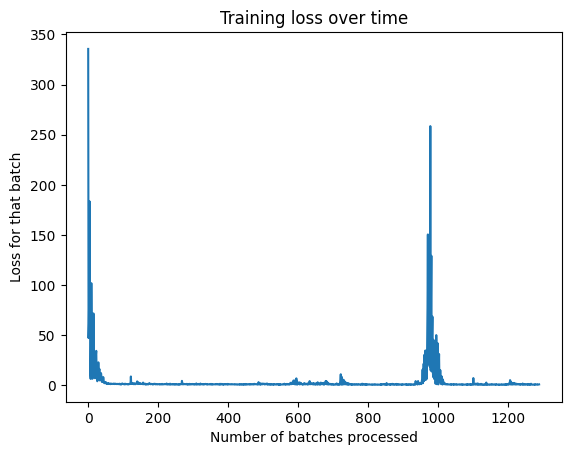

In [1]:
%run p09_datasetDataloaderAndBatching.ipynb

#### This module answers:

"What happens after training?" <br>
"How do I reuse this in a real project?"

### 1. Why this matters

In real projects:
- you don’t retrain every time
- training can take minutes / hours
- you train once, use many times

So we save the model.

### 2. Saving a trained model

In [2]:
torch.save(model.state_dict(), "Models/model.pth")
# PyTorcH model file (PTH)

Meaning:
- save only learned weights & bias
- file = reusable knowledge

### 3. Loading the model back

You must:
- recreate the same model structure
- then load weights

In [3]:
model = nn.Sequential(
    nn.Linear(X.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

model.load_state_dict(torch.load("Models/model.pth"))
model.eval()

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
)

.eval() means:

> "I am done training. I am only using the model to predict now."

What it does:
- turns off training-only behavior
- makes predictions stable and correct

Why this exists:
- some layers behave differently during training
- .eval() tells them to stop learning-time behavior

### 4. Using the model for prediction

In [4]:
new_X = X
# temporary fix (because i am too lazy to make a new X)

In [5]:
with torch.no_grad():
    prediction = model(new_X)

### 5. Where this fits in a bigger project

Typical structure:

- data preprocessing
- model training (once)
- save model
- load model in app
- predict repeatedly

Training ≠ deployment.